In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

Kolom numerik yang digunakan:
 - Berapa usia Anda saat ini?
 - Apa jenis destinasi wisata favorit Anda?
 - Berapa lama waktu liburan Anda biasanya (dalam hari)?
 - Dari mana sumber informasi wisata yang paling sering Anda gunakan?
 - Berapa besar anggaran liburan Anda?
 - Berapa hari dalam seminggu
 - Dengan siapa Anda biasanya
 - Moda transportasi apa yang paling sering Anda gunakan saat berlibur? (1=Mobil pribadi, 2=Pesawat, 3=Kereta, 4=Bus, 5=Motor/Kendaraan roda dua)
 - Apakah Anda lebih memilih wisata alam atau wisata kota? (1=Wisata alam, 2=Wisata kota, 3=Keduanya)
 - Berapa kali Anda berlibur dalam setahun?


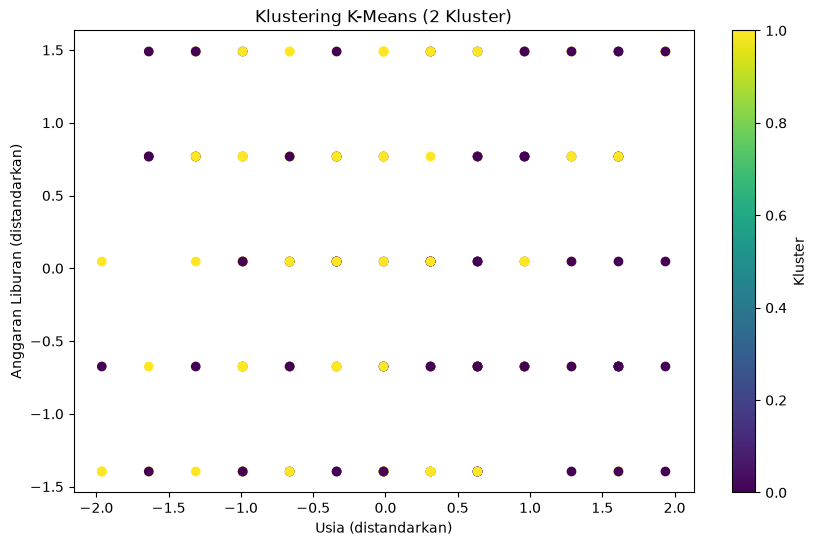

FILE 1: Hasil Kluster berhasil diekspor.
   Berapa usia Anda saat ini?  Apa jenis destinasi wisata favorit Anda?  \
0                          20                                         3   
1                          25                                         2   
2                          17                                         3   
3                          19                                         3   
4                          20                                         2   

   Berapa lama waktu liburan Anda biasanya (dalam hari)?  \
0                                                  4       
1                                                  4       
2                                                  1       
3                                                  2       
4                                                  2       

   Dari mana sumber informasi wisata yang paling sering Anda gunakan?  \
0                                                  1                    
1

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Memuat file Excel sesuai nama dataset Anda
jalur_file = 'surver liburan lokal.xlsx'
df = pd.read_excel(jalur_file, sheet_name='Form Responses 1')

# Seluruh kolom pada dataset ini sudah numerik, jadi dipakai semua sebagai fitur
kolom_numerik = df.select_dtypes(include='number').columns.tolist()
print("Kolom numerik yang digunakan:")
for k in kolom_numerik:
    print(" -", k)

# Praproses data dengan menstandardkan
skaler = StandardScaler()
data_distandarkan = skaler.fit_transform(df[kolom_numerik])

# Menerapkan K-Means klustering dengan 2 kluster
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(data_distandarkan)
df['Kluster'] = kmeans.labels_

# Plot kluster: sumbu X = Usia, sumbu Y = Anggaran liburan
idx_x = kolom_numerik.index('Berapa usia Anda saat ini?')
idx_y = kolom_numerik.index('Berapa besar anggaran liburan Anda?')

plt.figure(figsize=(10, 6))
plt.scatter(data_distandarkan[:, idx_x], data_distandarkan[:, idx_y], c=df['Kluster'], cmap='viridis')
plt.xlabel('Usia (distandarkan)')
plt.ylabel('Anggaran Liburan (distandarkan)')
plt.title('Klustering K-Means (2 Kluster)')
plt.colorbar(label='Kluster')
plt.show()

# FILE 1: Menyimpan dataframe dengan label kluster ke file baru
df.to_excel('Hasil_Kluster.xlsx', index=False)
print("FILE 1: Hasil Kluster berhasil diekspor.")
print(df.head())


In [3]:
# Membaca dataset hasil klustering
df = pd.read_excel('Hasil_Kluster.xlsx')
df


,Berapa usia Anda saat ini?,Apa jenis destinasi wisata favorit Anda?,Berapa lama waktu liburan Anda biasanya (dalam hari)?,Dari mana sumber informasi wisata yang paling sering Anda gunakan?,Berapa besar anggaran liburan Anda?,Berapa hari dalam seminggu,Dengan siapa Anda biasanya,"Moda transportasi apa yang paling sering Anda gunakan saat berlibur? (1=Mobil pribadi, 2=Pesawat, 3=Kereta, 4=Bus, 5=Motor/Kendaraan roda dua)","Apakah Anda lebih memilih wisata alam atau wisata kota? (1=Wisata alam, 2=Wisata kota, 3=Keduanya)",Berapa kali Anda berlibur dalam setahun?,Kluster
0,20,3,4,1,1,1,3,3,1,4,0
1,25,2,4,1,2,2,2,1,1,5,0
2,17,3,1,2,1,6,1,1,2,5,1
3,19,3,2,1,5,4,1,1,3,2,1
4,20,2,2,1,1,1,2,1,1,4,0
...,...,...,...,...,...,...,...,...,...,...,...
196,24,5,7,1,3,1,2,3,2,5,0
197,19,4,1,2,4,3,1,4,1,4,1
198,22,2,4,1,3,2,1,3,1,6,0
199,24,2,2,1,3,7,4,2,3,4,1


In [4]:
from sklearn.model_selection import train_test_split

# Pembagian Fitur (x) dan Target (y): fitur = kolom survei, target = label Kluster
x = df.drop(columns=['Kluster'])
y = df['Kluster']

# Split data menjadi training dan testing sets (80% : 20%)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Mengambil porsi data test saja untuk tujuan sinkronisasi laporan ekspor
fitur1_test, fitur2_test, fitur3_test = train_test_split(
    df['Berapa usia Anda saat ini?'],
    df['Berapa besar anggaran liburan Anda?'],
    df['Berapa kali Anda berlibur dalam setahun?'],
    test_size=0.2,
    random_state=42
)[1::2]

# Dictionary pemetaan label numerik ke teks kasus Klustering Liburan
label_map = {1: 'Kluster 1', 0: 'Kluster 0'}


In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Terapkan SMOTE untuk oversampling kelas minoritas
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

# Normalisasi data
scaler = StandardScaler()
x_train_nb = scaler.fit_transform(x_train_res)
x_test_nb = scaler.transform(x_test)

# Membuat & melatih model Gaussian Naive Bayes
model_nb = GaussianNB()
model_nb.fit(x_train_nb, y_train_res)

# Prediksi
y_pred_nb = model_nb.predict(x_test_nb)

# Evaluasi model
accuracy_nb = accuracy_score(y_test, y_pred_nb)
report_nb = classification_report(y_test, y_pred_nb, zero_division=1)
print("--- NAIVE BAYES ---")
print("Accuracy:", accuracy_nb)
print("Classification Report:\n", report_nb)

# Menggabungkan data uji dan hasil prediksi (disesuaikan dengan dataset liburan Anda)
results_nb = pd.DataFrame({
    'Usia': fitur1_test,
    'Anggaran Liburan': fitur2_test,
    'Frekuensi Liburan Setahun': fitur3_test,
    'Label Asli': y_test,
    'Prediksi': y_pred_nb
})

results_nb['Label Asli'] = results_nb['Label Asli'].map(label_map)
results_nb['Prediksi'] = results_nb['Prediksi'].map(label_map)

# Menyeleksi kolom saat ekspor
export_nb = results_nb[['Usia', 'Anggaran Liburan', 'Frekuensi Liburan Setahun', 'Label Asli', 'Prediksi']]

# FILE 2: Simpan ke file Excel
file_path_nb = 'Hasil Prediksi Naive Bayes.xlsx'
export_nb.to_excel(file_path_nb, index=False)
print(f"FILE 2: Hasil prediksi telah diekspor ke file: {file_path_nb}\n")


--- NAIVE BAYES ---
Accuracy: 0.9512195121951219
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.91      0.95        22
           1       0.90      1.00      0.95        19

    accuracy                           0.95        41
   macro avg       0.95      0.95      0.95        41
weighted avg       0.96      0.95      0.95        41

FILE 2: Hasil prediksi telah diekspor ke file: Hasil Prediksi Naive Bayes.xlsx



In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Menggunakan data resample dari SMOTE yang sama
x_train_rf = scaler.fit_transform(x_train_res)
x_test_rf = scaler.transform(x_test)

# Buat & Latih model Random Forest
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(x_train_rf, y_train_res)

# Prediksi pada data uji
y_pred_rf = model_rf.predict(x_test_rf)

# Evaluasi model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
report_rf = classification_report(y_test, y_pred_rf, zero_division=1)
print("--- RANDOM FOREST ---")
print("Accuracy:", accuracy_rf)
print("Classification Report:\n", report_rf)

# Gabungkan data uji dan hasil prediksi untuk Random Forest (disesuaikan dengan dataset liburan Anda)
results_rf = pd.DataFrame({
    'Usia': fitur1_test,
    'Anggaran Liburan': fitur2_test,
    'Frekuensi Liburan Setahun': fitur3_test,
    'Label Asli': y_test,
    'Prediksi': y_pred_rf
})

results_rf['Label Asli'] = results_rf['Label Asli'].map(label_map)
results_rf['Prediksi'] = results_rf['Prediksi'].map(label_map)

# Menyesuaikan nama kolom saat seleksi ekspor
export_rf = results_rf[['Usia', 'Anggaran Liburan', 'Frekuensi Liburan Setahun', 'Label Asli', 'Prediksi']]

# FILE 3: Simpan ke file Excel
file_path_rf = 'Hasil Prediksi Random Forest.xlsx'
export_rf.to_excel(file_path_rf, index=False)
print(f"FILE 3: Hasil prediksi telah diekspor ke file: {file_path_rf}\n")


--- RANDOM FOREST ---
Accuracy: 0.926829268292683
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93        22
           1       0.90      0.95      0.92        19

    accuracy                           0.93        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.93      0.93      0.93        41

FILE 3: Hasil prediksi telah diekspor ke file: Hasil Prediksi Random Forest.xlsx



In [7]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Terapkan SMOTE dan Normalisasi ulang sesuai alur SVM Anda
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)
x_train_svm = scaler.fit_transform(x_train_res)
x_test_svm = scaler.transform(x_test)

# Inisialisasi & Latih model SVM dengan kernel RBF
model_svm = SVC(kernel='rbf', random_state=42)
model_svm.fit(x_train_svm, y_train_res)

# Prediksi pada data uji
y_pred_svm = model_svm.predict(x_test_svm)

# Evaluasi model
accuracy_svm = accuracy_score(y_test, y_pred_svm)
report_svm = classification_report(y_test, y_pred_svm, zero_division=1)
print("--- SUPPORT VECTOR MACHINE ---")
print("Accuracy:", accuracy_svm)
print("Classification Report:\n", report_svm)

# Gabungkan data uji dan hasil prediksi SVM (disesuaikan dengan dataset liburan Anda)
results_svm = pd.DataFrame({
    'Usia': fitur1_test,
    'Anggaran Liburan': fitur2_test,
    'Frekuensi Liburan Setahun': fitur3_test,
    'Label Asli': y_test,
    'Prediksi': y_pred_svm
})

results_svm['Label Asli'] = results_svm['Label Asli'].map(label_map)
results_svm['Prediksi'] = results_svm['Prediksi'].map(label_map)

# Menyesuaikan nama kolom saat seleksi ekspor
export_svm = results_svm[['Usia', 'Anggaran Liburan', 'Frekuensi Liburan Setahun', 'Label Asli', 'Prediksi']]

# FILE 4: Simpan ke file Excel
file_path_svm = 'Hasil Prediksi SVM.xlsx'
export_svm.to_excel(file_path_svm, index=False)
print(f"FILE 4: Hasil prediksi telah diekspor ke file: {file_path_svm}")


--- SUPPORT VECTOR MACHINE ---
Accuracy: 0.926829268292683
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.86      0.93        22
           1       0.86      1.00      0.93        19

    accuracy                           0.93        41
   macro avg       0.93      0.93      0.93        41
weighted avg       0.94      0.93      0.93        41

FILE 4: Hasil prediksi telah diekspor ke file: Hasil Prediksi SVM.xlsx
